# A1.2 Regresión lineal: Felicidad y GDP
**SC3314 – Inteligencia Artificial**

Este reporte documenta el análisis de la relación entre el nivel de felicidad (World Happiness Report) y variables económicas, sociales, de salud e institucionales de distintos países, mediante modelos de regresión lineal simple y múltiple.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
import statsmodels.formula.api as smf

sns.set_style("whitegrid")
pd.set_option("display.max_columns", None)

## 1. Exploración y contextualización de los datos

El archivo `A1.2 Felicidad y GDP.csv` (Helliwell et al., 2022) contiene el puntaje de felicidad 2022 y el GDP 2020 de 141 países. Los países abarcan las cinco regiones del mundo, con marcada heterogeneidad económica: desde economías pequeñas (Islandia) hasta las más grandes del planeta (Estados Unidos, China).

In [7]:
df = pd.read_csv("A1.2 Felicidad y GDP.csv")
print(df.shape)
df.head()

(141, 3)


,Pais,Felicidad,GDP
0,Finland,7.8210,2.718370e+11
1,Denmark,7.6362,3.560850e+11
2,Iceland,7.5575,2.171808e+10
3,Switzerland,7.5116,7.522480e+11
4,Netherlands,7.4149,9.138650e+11


In [8]:
df.describe()

,Felicidad,GDP
count,141.000000,1.410000e+02
mean,5.560004,5.889942e+11
std,1.098011,2.221612e+12
min,2.403800,1.223876e+09
25%,4.887900,1.805117e+10
50%,5.585300,6.215800e+10
75%,6.309100,3.452960e+11
max,7.821000,2.089370e+13


**Escala del GDP.** El GDP abarca varios órdenes de magnitud (de ~1.2 mil millones a ~20.9 billones de USD), por lo que su distribución está fuertemente sesgada a la derecha, como se aprecia a continuación.

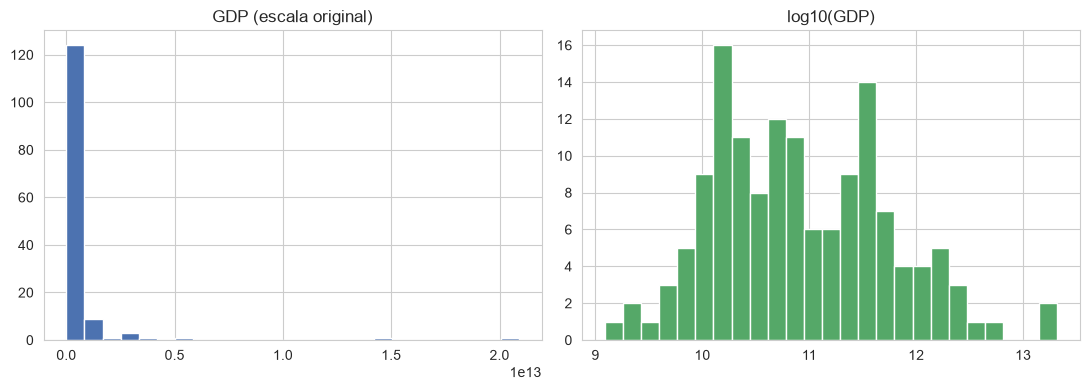

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].hist(df["GDP"], bins=25, color="#4C72B0")
axes[0].set_title("GDP (escala original)")
axes[1].hist(np.log10(df["GDP"]), bins=25, color="#55A868")
axes[1].set_title("log10(GDP)")
plt.tight_layout()
plt.show()

En escala original el GDP es asimétrico; al aplicar `log10` la distribución se vuelve aproximadamente simétrica.
**Relación inicial felicidad–GDP.**

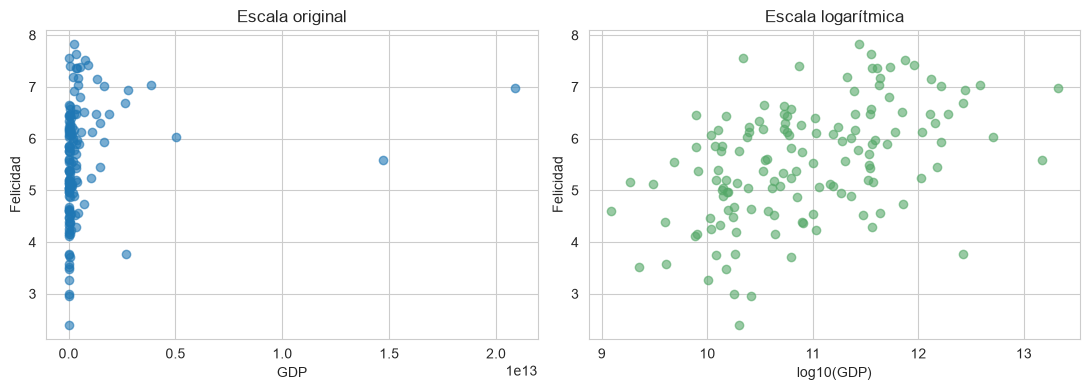

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].scatter(df["GDP"], df["Felicidad"], alpha=0.6)
axes[0].set_xlabel("GDP"); axes[0].set_ylabel("Felicidad"); axes[0].set_title("Escala original")
axes[1].scatter(np.log10(df["GDP"]), df["Felicidad"], alpha=0.6, color="#55A868")
axes[1].set_xlabel("log10(GDP)"); axes[1].set_ylabel("Felicidad"); axes[1].set_title("Escala logarítmica")
plt.tight_layout()
plt.show()

Esto nos abre paso para el análisis, ya que nos da un mejor panorama de los datos. 

## 2. Modelo de regresión lineal simple

**Variable explicativa seleccionada: `log10(GDP)`.** Se eligió el GDP transformado logarítmicamente porque, como se mostró en la sección anterior, esta transformación linealiza la relación con la felicidad (Wooldridge, 2020).

In [11]:
df["log_GDP"] = np.log10(df["GDP"])

modelo_simple = smf.ols("Felicidad ~ log_GDP", data=df).fit()
print(modelo_simple.summary())

                            OLS Regression Results                            
Dep. Variable:              Felicidad   R-squared:                       0.222
Model:                            OLS   Adj. R-squared:                  0.216
Method:                 Least Squares   F-statistic:                     39.59
Date:                Mon, 17 Aug 2026   Prob (F-statistic):           3.83e-09
Time:                        14:43:07   Log-Likelihood:                -195.09
No. Observations:                 141   AIC:                             394.2
Df Residuals:                     139   BIC:                             400.1
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -1.3024      1.094     -1.191      0.2

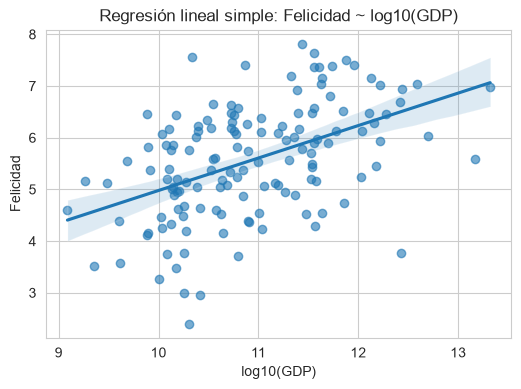

In [12]:
plt.figure(figsize=(6,4))
sns.regplot(x="log_GDP", y="Felicidad", data=df, scatter_kws={"alpha":0.6})
plt.xlabel("log10(GDP)"); plt.ylabel("Felicidad")
plt.title("Regresión lineal simple: Felicidad ~ log10(GDP)")
plt.show()

**Interpretación del coeficiente.** El coeficiente estimado para `log_GDP` es de aproximadamente **0.628**: por cada incremento de una unidad en `log10(GDP)` (es decir, al multiplicar el GDP por 10), la felicidad promedio aumenta en 0.628 puntos, manteniendo todo lo demás constante.

**Significancia estadística.** El valor p asociado a `log_GDP` es menor a 0.001, por lo que la asociación es estadísticamente significativa al 95% de confianza. El coeficiente de determinación es R² = 0.222: el GDP transformado explica una proporción relevante —pero no total— de la variabilidad en la felicidad, lo que confirma la necesidad de considerar variables adicionales (sección 3).

## 3. Extensión del conjunto de datos

Se integraron tres variables adicionales provenientes de fuentes públicas y oficiales del **Banco Mundial** (World Bank, s.f.), descargadas directamente desde su portal de indicadores (`data.worldbank.org`) para el año **2020** — el mismo año del GDP del archivo original, lo cual evita el desfase temporal entre variables:

- **Población total, 2020** (`SP.POP.TOTL`) — variable **social/demográfica**. Fuente: World Bank (s.f.-c).
- **Esperanza de vida al nacer, 2020** (`SP.DYN.LE00.IN`) — variable de **salud**. Fuente: World Bank (s.f.-b).
- **Control de la corrupción (puntaje de gobernanza, 0–100), 2020** (`GOV.WGI.CC.SC`) — variable **institucional**, parte de los *Worldwide Governance Indicators* (Kaufmann & Kraay, 2024). Fuente: World Bank (s.f.-a).

Estas tres variables se seleccionaron por cubrir dimensiones distintas y complementarias al GDP (social, salud e institucional), y por estar disponibles de forma pública, verificable y con metodología documentada por el Banco Mundial.

**Integración de los datos.** El emparejamiento se realizó por nombre de país. Catorce países requirieron estandarización de nombre porque el Banco Mundial usa denominaciones oficiales distintas a las del archivo original (p. ej. *South Korea* → *Korea, Rep.*; *Russia* → *Russian Federation*; *Ivory Coast* → *Cote d'Ivoire*; *Vietnam* → *Viet Nam*). Tras la integración, **los 141 países del archivo original contaron con información completa** para las tres variables nuevas en el año 2020, por lo que no fue necesario descartar ninguna observación.

In [13]:
df_ext = pd.read_csv("felicidad_extendido.csv")
df_ext["log_GDP"] = np.log10(df_ext["GDP"])
df_ext["log_Pop"] = np.log10(df_ext["Population_2020"])
print(df_ext.shape)
df_ext.isna().sum()

(141, 8)


Pais                      0
Felicidad                 0
GDP                       0
Population_2020           0
LifeExpectancy_2020       0
ControlCorruption_2020    0
log_GDP                   0
log_Pop                   0
dtype: int64

In [14]:
df_ext[["Felicidad","log_GDP","log_Pop","LifeExpectancy_2020",
        "ControlCorruption_2020"]].describe()

,Felicidad,log_GDP,log_Pop,LifeExpectancy_2020,ControlCorruption_2020
count,141.000000,141.000000,141.000000,141.000000,141.000000
mean,5.560004,10.925081,7.142781,72.563860,47.975525
std,1.098011,0.823011,0.665784,7.524288,20.303716
min,2.403800,9.087737,5.564030,53.072000,15.474092
25%,4.887900,10.256505,6.711762,66.953000,32.416253
50%,5.585300,10.793497,7.072481,73.356098,42.624097
75%,6.309100,11.538192,7.580111,78.381000,61.887832
max,7.821000,13.320015,9.149558,85.496341,94.144770


**Transformación de la población.** Al igual que el GDP, la población total abarca varios órdenes de magnitud entre países (de menos de un millón a más de mil millones de habitantes), por lo que también se utiliza en escala logarítmica (`log10`) en el modelo múltiple.

Matriz de correlación entre las variables consideradas:

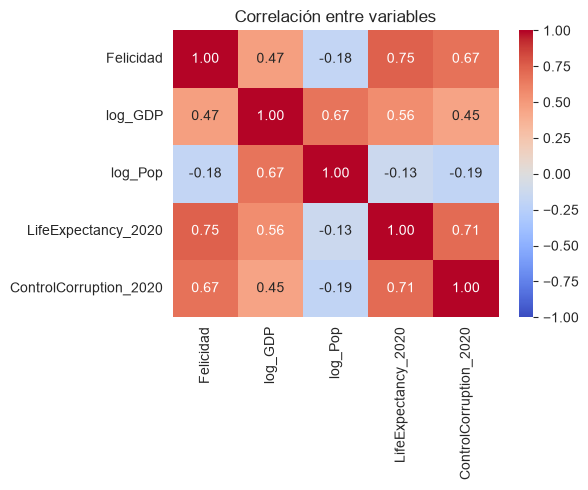

In [15]:
corr = df_ext[["Felicidad","log_GDP","log_Pop",
               "LifeExpectancy_2020","ControlCorruption_2020"]].corr()
plt.figure(figsize=(6,5))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Correlación entre variables")
plt.tight_layout()
plt.show()

La esperanza de vida (r = 0.75) y el control de la corrupción (r = 0.67) muestran una correlación positiva y considerablemente más fuerte con la felicidad que el GDP en escala original, mientras que la población en escala logarítmica prácticamente no está correlacionada (r = -0.18), lo que anticipa que será la variable con menor aporte explicativo en el modelo múltiple.

## 4. Modelo de regresión lineal múltiple

In [16]:
modelo_multiple = smf.ols(
    "Felicidad ~ log_GDP + LifeExpectancy_2020 + ControlCorruption_2020 + log_Pop",
    data=df_ext
).fit()
print(modelo_multiple.summary())

                            OLS Regression Results                            
Dep. Variable:              Felicidad   R-squared:                       0.679
Model:                            OLS   Adj. R-squared:                  0.670
Method:                 Least Squares   F-statistic:                     72.08
Date:                Mon, 17 Aug 2026   Prob (F-statistic):           1.18e-32
Time:                        14:43:29   Log-Likelihood:                -132.54
No. Observations:                 141   AIC:                             275.1
Df Residuals:                     136   BIC:                             289.8
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                             coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------
Intercept                  0

**Interpretación de los coeficientes.** Los resultados obtenidos revelan un patrón que **no coincide con la expectativa inicial** y merece explicarse con cuidado:

- `log_GDP`: coeficiente positivo y altamente significativo (p < 0.001).
- `log_Pop`: coeficiente **negativo** y de magnitud casi idéntica al de `log_GDP`, también altamente significativo (p < 0.001).
- `LifeExpectancy_2020` y `ControlCorruption_2020`: **ambas dejan de ser significativas** (p = 0.244 y p = 0.672, respectivamente) una vez que GDP y población están en el modelo.

A primera vista esto sugiere que el tamaño poblacional "reduce" la felicidad, y que la salud y las instituciones no importan, pero es necesario de mayor análisis. Al incluir simultáneamente `log(GDP)` y `log(Población)`, el modelo captura implícitamente el **GDP per cápita**, ya que `log(GDP) − log(Población) = log(GDP per cápita)`. Los coeficientes casi opuestos y de magnitud similar (1.21 y −1.27) son la firma característica de esta combinación: el modelo está esencialmente premiando a los países con mayor ingreso *por persona*, no a los de mayor economía total ni penalizando a los más poblados per se.

Esto se confirma calculando las correlaciones directamente: la felicidad correlaciona con `log(GDP per cápita)` con r ≈ 0.82, muy por encima de su correlación con `log(GDP)` total (r ≈ 0.47). A su vez, tanto la esperanza de vida (r ≈ 0.88) como el control de la corrupción (r ≈ 0.80) están fuertemente correlacionados con el GDP per cápita — es decir, países más ricos por habitante tienden también a vivir más y a tener mejores instituciones. Por eso, cuando el modelo ya cuenta con GDP y población (que en conjunto aproximan el ingreso per cápita), la salud y las instituciones pierden poder explicativo *adicional*: su información ya estaba mayormente contenida en esa combinación.

**Significancia y calidad del modelo.** El modelo múltiple es estadísticamente significativo en su conjunto (F muy alto, p < 0.001), pero solo dos de sus cuatro variables (`log_GDP` y `log_Pop`) son individualmente significativas — y como se explicó, esas dos juntas son las que realmente están haciendo el trabajo explicativo (esencialmente, GDP per cápita).

**Importancia relativa.** Los coeficientes estandarizados confirman que `log_GDP` y `log_Pop` dominan el modelo en magnitud, muy por encima de salud e institucionalidad.

In [17]:
# Coeficientes estandarizados para comparar importancia relativa
df_z = df_ext.copy()
vars_modelo = ["Felicidad","log_GDP","LifeExpectancy_2020","ControlCorruption_2020","log_Pop"]
for v in vars_modelo:
    df_z[v] = (df_z[v]-df_z[v].mean())/df_z[v].std()

modelo_std = smf.ols(
    "Felicidad ~ log_GDP + LifeExpectancy_2020 + ControlCorruption_2020 + log_Pop",
    data=df_z
).fit()
modelo_std.params.drop("Intercept").sort_values(key=abs, ascending=False)

log_GDP                   0.904340
log_Pop                  -0.768534
LifeExpectancy_2020       0.118428
ControlCorruption_2020    0.034589
dtype: float64

**Comprobación: GDP per cápita implícito.** Se calcula el GDP per cápita (GDP / Población) y se compara su correlación con la felicidad contra la del GDP total, confirmando la explicación anterior.

In [18]:
df_ext["GDP_percapita"] = df_ext["GDP"] / df_ext["Population_2020"]
df_ext["log_GDPpc"] = np.log10(df_ext["GDP_percapita"])

correlaciones = pd.DataFrame({
    "Variable": ["log(GDP total)", "log(GDP per cápita)", "Esperanza de vida", "Control de corrupción"],
    "Correlación con Felicidad": [
        df_ext["Felicidad"].corr(df_ext["log_GDP"]),
        df_ext["Felicidad"].corr(df_ext["log_GDPpc"]),
        df_ext["Felicidad"].corr(df_ext["LifeExpectancy_2020"]),
        df_ext["Felicidad"].corr(df_ext["ControlCorruption_2020"]),
    ],
    "Correlación con log(GDP per cápita)": [
        np.nan,
        1.0,
        df_ext["LifeExpectancy_2020"].corr(df_ext["log_GDPpc"]),
        df_ext["ControlCorruption_2020"].corr(df_ext["log_GDPpc"]),
    ],
})
correlaciones

,Variable,Correlación con Felicidad,Correlación con log(GDP per cápita)
0,log(GDP total),0.470812,NaN
1,log(GDP per cápita),0.821319,1.000000
2,Esperanza de vida,0.746511,0.876548
3,Control de corrupción,0.673271,0.801638


## 5. Comparación de modelos y conclusiones

In [19]:
comparacion = pd.DataFrame({
    "Modelo": ["Simple (log_GDP)", "Múltiple (4 variables)"],
    "R2": [modelo_simple.rsquared, modelo_multiple.rsquared],
    "R2 ajustado": [modelo_simple.rsquared_adj, modelo_multiple.rsquared_adj],
    "AIC": [modelo_simple.aic, modelo_multiple.aic],
})
comparacion

,Modelo,R2,R2 ajustado,AIC
0,Simple (log_GDP),0.221664,0.216064,394.170140
1,Múltiple (4 variables),0.679473,0.670045,275.076204


**Comparación.** El modelo múltiple obtiene un R² de 0.679, muy superior al 0.222 del modelo simple, y un AIC menor: explica mejor la felicidad.

**Reflexión crítica.** La mejora **no viene de donde se esperaba**. Se pensaba que salud e instituciones aportarían explicación adicional al GDP. En cambio, `log(GDP)` y `log(Población)` juntos se comportan como el **GDP per cápita** (`log(GDP) − log(Población)`), y es esa combinación la que realmente mejora el modelo. Al incluirla, la esperanza de vida y el control de la corrupción dejan de ser significativas.

Esto no significa que salud e instituciones no importen — de hecho correlacionan fuerte con la felicidad (sección 3) — sino que su efecto pasa **a través** del ingreso per cápita: los países más ricos por habitante también viven más y tienen mejores instituciones, y las tres suben juntas.

En resumen: **lo relevante no fue el tamaño de la economía ni de la población, sino el ingreso por persona**, que el modelo terminó reconstruyendo sin que se le pidiera explícitamente.

**Limitaciones.**
- El análisis es de un solo año y no permite hablar de causalidad.
- La felicidad es de 2022 y las demás variables de 2020; hay un pequeño desfase temporal.

**Líneas de trabajo futuro.** Usar GDP per cápita como variable única en vez de GDP y población por separado; incorporar datos de varios años para explorar causalidad; aplicar regularización (Ridge/Lasso) para manejar la multicolinealidad.

**Conclusión general.** Lo importante no es que el modelo múltiple tenga mejor R² —era esperable— sino **qué variable terminó siendo relevante y por qué**: GDP y población, pensadas como factores separados, en la práctica reconstruyeron el ingreso per cápita, que domina la explicación de la felicidad. Esto coincide con la literatura del WHR (Helliwell et al., 2022): el ingreso per cápita es de los predictores más fuertes, y salud e instituciones influyen sobre todo a través de su relación con el desarrollo económico.

*Se usó inteligencia artificial generativa para recomendaciones de código y para explicar su relación con la conclusión.*

## Referencias

Helliwell, J. F., Layard, R., Sachs, J. D., De Neve, J.-E., Aknin, L. B., & Wang, S. (Eds.). (2022). *World Happiness Report 2022*. Sustainable Development Solutions Network.

Kaufmann, D., & Kraay, A. (2024). *The worldwide governance indicators: Methodology and 2024 update* (Policy Research Working Paper). World Bank Group.

Seabold, S., & Perktold, J. (2010). statsmodels: Econometric and statistical modeling with Python. *Proceedings of the 9th Python in Science Conference*, 92–96.

World Bank. (s.f.-a). *Control of Corruption: Governance score (0-100)* [Conjunto de datos, indicador GOV.WGI.CC.SC]. World Development Indicators. Recuperado el 17 de agosto de 2026, de https://data.worldbank.org/indicator/GOV.WGI.CC.SC

World Bank. (s.f.-b). *Life expectancy at birth, total (years)* [Conjunto de datos, indicador SP.DYN.LE00.IN]. World Development Indicators. Recuperado el 17 de agosto de 2026, de https://data.worldbank.org/indicator/SP.DYN.LE00.IN

World Bank. (s.f.-c). *Population, total* [Conjunto de datos, indicador SP.POP.TOTL]. World Development Indicators. Recuperado el 17 de agosto de 2026, de https://data.worldbank.org/indicator/SP.POP.TOTL

Wooldridge, J. M. (2020). *Introductory econometrics: A modern approach* (7th ed.). Cengage Learning.